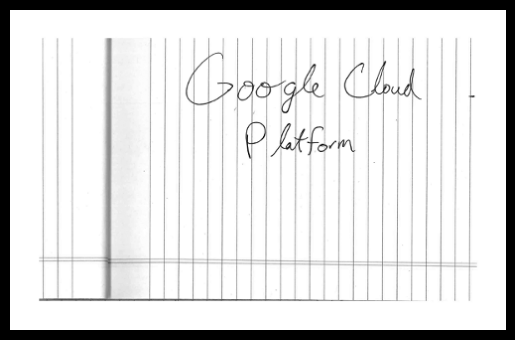

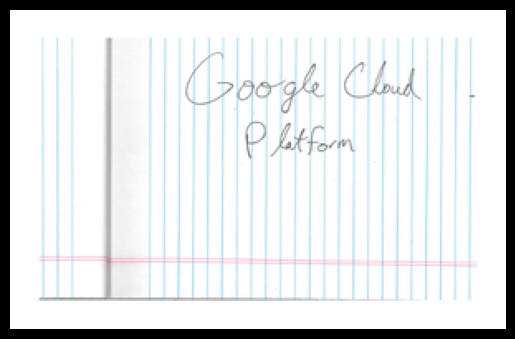

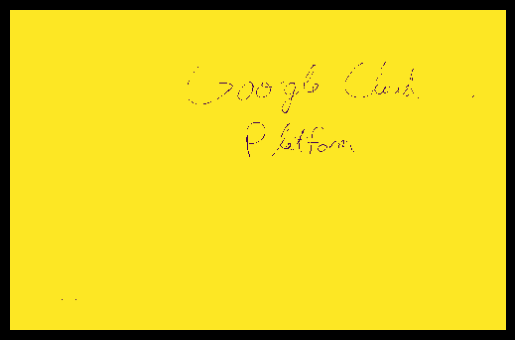

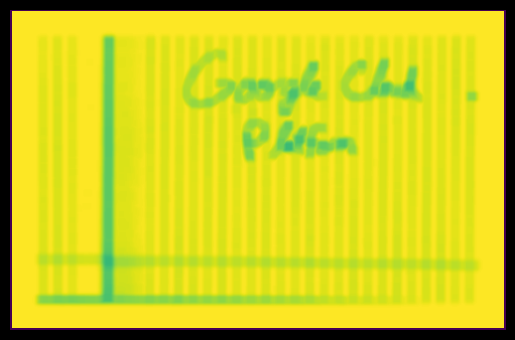

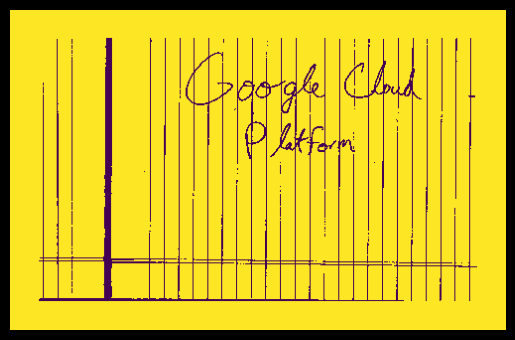

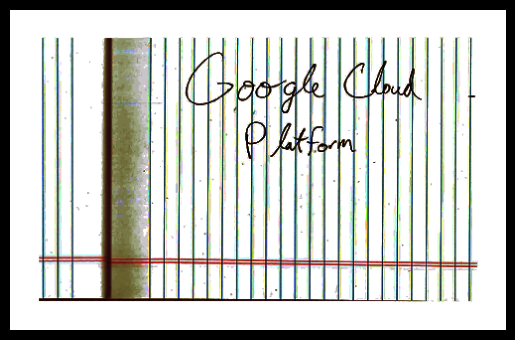

In [4]:
import numpy as np
from PIL import Image, ImageOps, ImageFilter
from matplotlib import pyplot as plt

imagePrev = Image.open('images/test1.png')

def show_one_image(image_to_plot,cmap=None):
    plt.imshow(image_to_plot,cmap=cmap)
    plt.axis('off')
    plt.show()

#metode de imbunatatire

def normalization(image):
    gray = ImageOps.grayscale(image)
    arr = np.array(gray, dtype=np.float32)
    arr_norm = 255 * (arr - arr.min()) / (arr.max() - arr.min())
    return Image.fromarray(arr_norm.astype(np.uint8))
show_one_image(normalization(imagePrev),cmap='gray')

def image_scaling(image):
    width, height = image.size
    current_resolution = max(width, height)
    factor = 300 / current_resolution
    new_width = int(width * factor)
    new_height = int(height * factor)
    return image.resize((new_width, new_height), Image.Resampling.LANCZOS)
show_one_image(image_scaling(imagePrev))

def binarization(image):
    gray = ImageOps.grayscale(image)
    arr = np.array(gray)
    binary_arr = np.where(arr > 127, 255, 0).astype(np.uint8)
    return Image.fromarray(binary_arr)
show_one_image(binarization(imagePrev))

def noise_removal(image):
    gray = ImageOps.grayscale(image)
    blurred = gray.filter(ImageFilter.GaussianBlur(2))  # aprox kernel 5x5
    arr = np.array(blurred)
    kernel_size = 5
    padded = np.pad(arr, ((kernel_size//2, kernel_size//2), (kernel_size//2, kernel_size//2)), mode='constant', constant_values=0)
    opened = np.copy(arr)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            opened[i, j] = np.min(region)
    return Image.fromarray(opened)
show_one_image(noise_removal(imagePrev))

def thresholding(image):
    gray = ImageOps.grayscale(image)
    arr = np.array(gray)
    hist, _ = np.histogram(arr, bins=256, range=(0, 256))
    total = arr.size
    current_max, threshold = 0, 0
    sum_total, sum_foreground, weight_background = 0, 0, 0
    for i in range(256):
        sum_total += i * hist[i]
    weight_background = 0
    sum_background = 0
    for i in range(256):
        weight_background += hist[i]
        if weight_background == 0:
            continue
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break
        sum_background += i * hist[i]
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        between = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
        if between > current_max:
            current_max = between
            threshold = i
    binary_arr = np.where(arr > threshold, 255, 0).astype(np.uint8)
    return Image.fromarray(binary_arr)
show_one_image(thresholding(normalization(imagePrev)))

def enhance_contrast(image):
    if image.mode != 'RGB':

        gray = ImageOps.grayscale(image)
        eq = ImageOps.equalize(gray)
        return eq.convert('RGB')
    else:

        r, g, b = image.split()
        r_eq = ImageOps.equalize(r)
        g_eq = ImageOps.equalize(g)
        b_eq = ImageOps.equalize(b)
        return Image.merge('RGB', (r_eq, g_eq, b_eq))
show_one_image(enhance_contrast(imagePrev))
